### HOPE DOES NOT DISAPPOINT

# PREDICTING CROP PRODUCTION BASED ON AGRICULTURAL DATA

## PROBLEM STATEMENT: 

#### - To forecast crop production for crops grown in a specific region

## OBJECTIVES:
#### - To analyse different factors that influence crop production
#### - To predict the crop production (in tonnes)

## PHASES:
#### 1. Understanding the Problem Statement
#### 2. Procuring the Data
#### 3. Data Cleaning and Preprocessing
#### 4. Exploratory Data Analysis
#### 5. Building and Validating the Model
#### 6. Performance Comparison
#### 7. Inferences
#### 8. Actionable Insights

## STEP 1: UNDERSTANDING THE PROBLEM STATEMENT
#### -  Typical Regression Problem: Crop Production - Target variable
#### -  Requirement: Regression Model

## STEP 2:  PROCURING THE DATA

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

plt.style.use("bmh")

In [2]:
df = pd.read_csv("FAOSTAT_data.csv")

## STEP 3: DATA CLEANING AND PREPROCESSING

#### 3.1 SANITY CHECK

In [3]:
df.shape

(224647, 15)

In [4]:
df.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2019,2019,ha,29203.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2019,2019,kg/ha,1308.3,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,1371,"Almonds, in shell",2019,2019,t,38205.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,1371,"Almonds, in shell",2020,2020,ha,22134.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,1371,"Almonds, in shell",2020,2020,kg/ha,1775.9,A,Official figure,NaN


In [5]:
df.columns

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

In [6]:
df.isnull().sum()

Domain Code              0
Domain                   0
Area Code (M49)          0
Area                     0
Element Code             0
Element                  0
Item Code (CPC)          5
Item                     0
Year Code                0
Year                     0
Unit                     2
Value                 6517
Flag                     4
Flag Description        13
Note                219549
dtype: int64

#### 3.2 PREPROCESSING

#### CHALLENGE 1:
##### - Target variable (Production) is not present as a separate column
##### - Element Column contains 3 different values: Area Harvested (in ha), Yield (kg/ha), Production (in tons)

#### Solution: FEATURE ENGINEERING
##### - Using existing data, 3 new columns should be created Area Harvested, Yield, Production

#### CHALLENGE 2:
##### - Creating these 3 new columns is not straightforward

#### Reason:
##### Dependent Data

#### Solution:

##### Step 1: 4 new tables are created after identifying the essential non-redundant data.

##### Table 1. Area Harvested
##### Table 2. Yield 
##### Table 3. Production


##### Step 2: Merge these 3 tables

In [8]:
# Choosing the Significant Features for Prediction
significant_features_df = df.drop(columns=['Domain Code','Domain','Area Code (M49)','Element Code','Item Code (CPC)','Year Code','Flag', 'Flag Description', 'Note'])
significant_features_df

,Area,Element,Item,Year,Unit,Value
0,Afghanistan,Area harvested,"Almonds, in shell",2019,ha,29203.00
1,Afghanistan,Yield,"Almonds, in shell",2019,kg/ha,1308.30
2,Afghanistan,Production,"Almonds, in shell",2019,t,38205.00
3,Afghanistan,Area harvested,"Almonds, in shell",2020,ha,22134.00
4,Afghanistan,Yield,"Almonds, in shell",2020,kg/ha,1775.90
...,...,...,...,...,...,...
224642,Zimbabwe,Production,"Whole milk, evaporated",2019,t,5010.21
224643,Zimbabwe,Production,"Whole milk, evaporated",2020,t,4795.70
224644,Zimbabwe,Production,"Whole milk, evaporated",2021,t,4921.05
224645,Zimbabwe,Production,"Whole milk, evaporated",2022,t,4966.37


#### 3.2.1 Area Harvested Table

In [9]:
area_harvested_table = df[df['Element'] == 'Area harvested'][['Area','Element', 'Item', 'Year', 'Value'
      ]].rename(columns={'Value': 'Area_harvested'})
area_harvested_table

,Area,Element,Item,Year,Area_harvested
0,Afghanistan,Area harvested,"Almonds, in shell",2019,29203.0
3,Afghanistan,Area harvested,"Almonds, in shell",2020,22134.0
6,Afghanistan,Area harvested,"Almonds, in shell",2021,36862.0
9,Afghanistan,Area harvested,"Almonds, in shell",2022,36462.0
12,Afghanistan,Area harvested,"Almonds, in shell",2023,37000.0
...,...,...,...,...,...
224619,Zimbabwe,Area harvested,Wheat,2019,24186.0
224622,Zimbabwe,Area harvested,Wheat,2020,44466.0
224625,Zimbabwe,Area harvested,Wheat,2021,66434.0
224628,Zimbabwe,Area harvested,Wheat,2022,48504.0


In [10]:
area_harvested_table.isnull().sum()

Area                 0
Element              0
Item                 0
Year                 0
Area_harvested    2408
dtype: int64

#### 3.2.2 Yield Table

In [11]:
yield_table = df[df['Element'] == 'Yield'][['Area','Element', 'Item', 'Year', 'Value'
      ]].rename(columns={'Value': 'Yield'})
yield_table

,Area,Element,Item,Year,Yield
1,Afghanistan,Yield,"Almonds, in shell",2019,1308.3
4,Afghanistan,Yield,"Almonds, in shell",2020,1775.9
7,Afghanistan,Yield,"Almonds, in shell",2021,1743.2
10,Afghanistan,Yield,"Almonds, in shell",2022,1742.0
13,Afghanistan,Yield,"Almonds, in shell",2023,1810.8
...,...,...,...,...,...
224620,Zimbabwe,Yield,Wheat,2019,3914.9
224623,Zimbabwe,Yield,Wheat,2020,4779.6
224626,Zimbabwe,Yield,Wheat,2021,5075.9
224629,Zimbabwe,Yield,Wheat,2022,5154.2


In [12]:
yield_table.isnull().sum()

Area       0
Element    0
Item       0
Year       0
Yield      0
dtype: int64

#### 3.2.3 Production Table

In [13]:
production_table = df[df['Element'] == 'Production'][['Area','Element', 'Item', 'Year', 'Value'
      ]].rename(columns={'Value': 'Production'})
production_table

,Area,Element,Item,Year,Production
2,Afghanistan,Production,"Almonds, in shell",2019,38205.00
5,Afghanistan,Production,"Almonds, in shell",2020,39307.00
8,Afghanistan,Production,"Almonds, in shell",2021,64256.00
11,Afghanistan,Production,"Almonds, in shell",2022,63515.00
14,Afghanistan,Production,"Almonds, in shell",2023,67000.00
...,...,...,...,...,...
224642,Zimbabwe,Production,"Whole milk, evaporated",2019,5010.21
224643,Zimbabwe,Production,"Whole milk, evaporated",2020,4795.70
224644,Zimbabwe,Production,"Whole milk, evaporated",2021,4921.05
224645,Zimbabwe,Production,"Whole milk, evaporated",2022,4966.37


In [14]:
production_table.isnull().sum()

Area             0
Element          0
Item             0
Year             0
Production    3362
dtype: int64

#### 3.3 DATA CLEANING

##### 3.3.1 Dropping the Column 'Element'

In [15]:
area_harvested_table=area_harvested_table.drop(columns=['Element'])
yield_table=yield_table.drop(columns=['Element'])
production_table=production_table.drop(columns=['Element'])

##### 3.3.2 Merging 3 Tables

In [16]:
feature_engineered_df = production_table.merge(yield_table, 
                                               on=['Area', 'Item','Year'], 
                                               how='inner').merge(area_harvested_table, 
                                                                  on=['Area', 'Item','Year'], 
                                                                  how='inner')
feature_engineered_df

,Area,Item,Year,Production,Yield,Area_harvested
0,Afghanistan,"Almonds, in shell",2019,38205.0,1308.3,29203.0
1,Afghanistan,"Almonds, in shell",2020,39307.0,1775.9,22134.0
2,Afghanistan,"Almonds, in shell",2021,64256.0,1743.2,36862.0
3,Afghanistan,"Almonds, in shell",2022,63515.0,1742.0,36462.0
4,Afghanistan,"Almonds, in shell",2023,67000.0,1810.8,37000.0
...,...,...,...,...,...,...
44976,Zimbabwe,Wheat,2019,94685.0,3914.9,24186.0
44977,Zimbabwe,Wheat,2020,212530.0,4779.6,44466.0
44978,Zimbabwe,Wheat,2021,337212.0,5075.9,66434.0
44979,Zimbabwe,Wheat,2022,250000.0,5154.2,48504.0


In [17]:
feature_engineered_df.to_csv("feature_engineered.csv")

In [18]:
feature_engineered_df.isnull().sum()

Area              0
Item              0
Year              0
Production        0
Yield             0
Area_harvested    0
dtype: int64

## STEP 4: EXPLORATORY DATA ANALYSIS

In [19]:
# Step 1: Load the data
df = pd.read_csv('feature_engineered.csv')
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (44981, 7)

First few rows:
   Unnamed: 0         Area               Item  Year  Production   Yield  \
0           0  Afghanistan  Almonds, in shell  2019     38205.0  1308.3   
1           1  Afghanistan  Almonds, in shell  2020     39307.0  1775.9   
2           2  Afghanistan  Almonds, in shell  2021     64256.0  1743.2   
3           3  Afghanistan  Almonds, in shell  2022     63515.0  1742.0   
4           4  Afghanistan  Almonds, in shell  2023     67000.0  1810.8   

   Area_harvested  
0         29203.0  
1         22134.0  
2         36862.0  
3         36462.0  
4         37000.0  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44981 entries, 0 to 44980
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      44981 non-null  int64  
 1   Area            44981 non-null  object 
 2   Item            44981 non-null  object 
 3   Year            44981 non-null  i

## 4.1. Crop Distribution Analysis

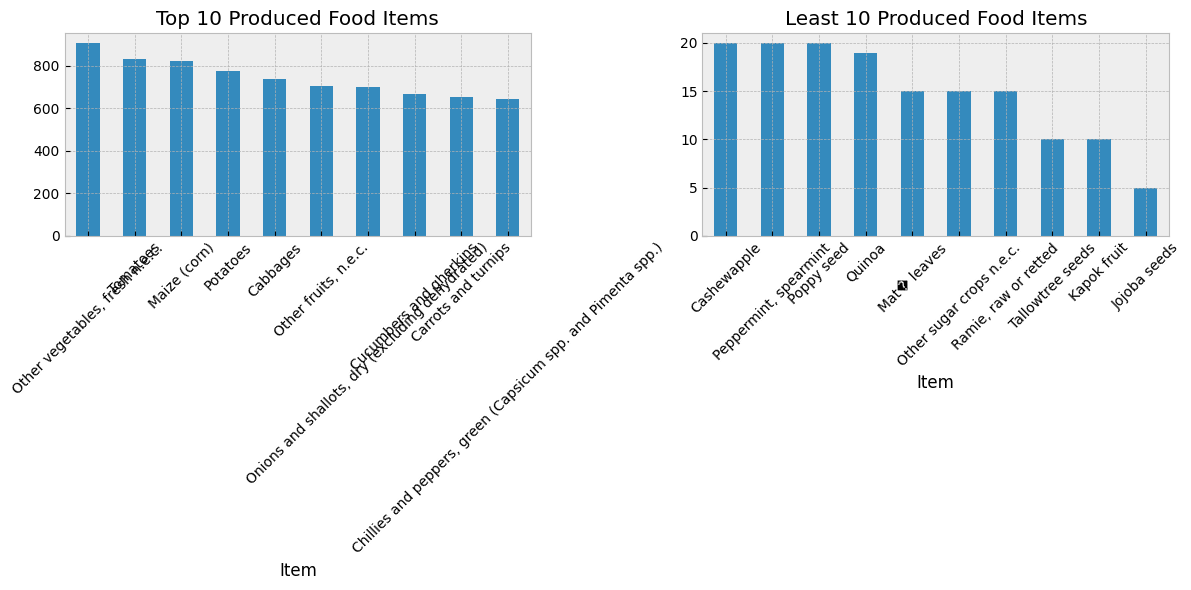

In [20]:
plt.figure(figsize=(12, 6))
top_crops = df['Item'].value_counts().head(10)
plt.subplot(1, 2, 1)
top_crops.plot(kind='bar')
plt.title('Top 10 Produced Food Items')
plt.xticks(rotation=45)
plt.tight_layout()

plt.subplot(1, 2, 2)
bottom_crops = df['Item'].value_counts().tail(10)
bottom_crops.plot(kind='bar')
plt.title('Least 10 Produced Food Items')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('crop_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.2 Temporal Analysis

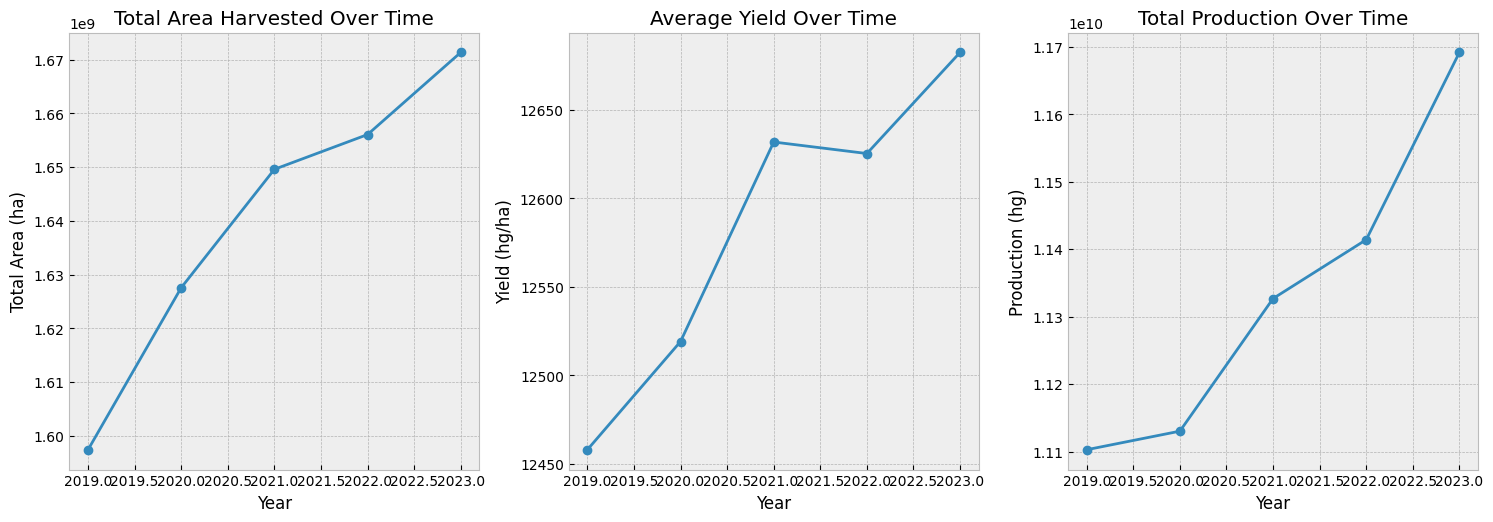

In [21]:
##  Yearly Trends for key metrics
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
yearly_area = df.groupby('Year')['Area_harvested'].sum()
yearly_area.plot(kind='line', marker='o')
plt.title('Total Area Harvested Over Time')
plt.ylabel('Total Area (ha)')

plt.subplot(2, 3, 2)
yearly_yield = df.groupby('Year')['Yield'].mean()
yearly_yield.plot(kind='line', marker='o')
plt.title('Average Yield Over Time')
plt.ylabel('Yield (hg/ha)')

plt.subplot(2, 3, 3)
yearly_production = df.groupby('Year')['Production'].sum()
yearly_production.plot(kind='line', marker='o')
plt.title('Total Production Over Time')
plt.ylabel('Production (hg)')

plt.tight_layout()
plt.savefig('yearly_trends.png', dpi=300, bbox_inches='tight')
plt.show()

## 4.3 Comparative Analysis

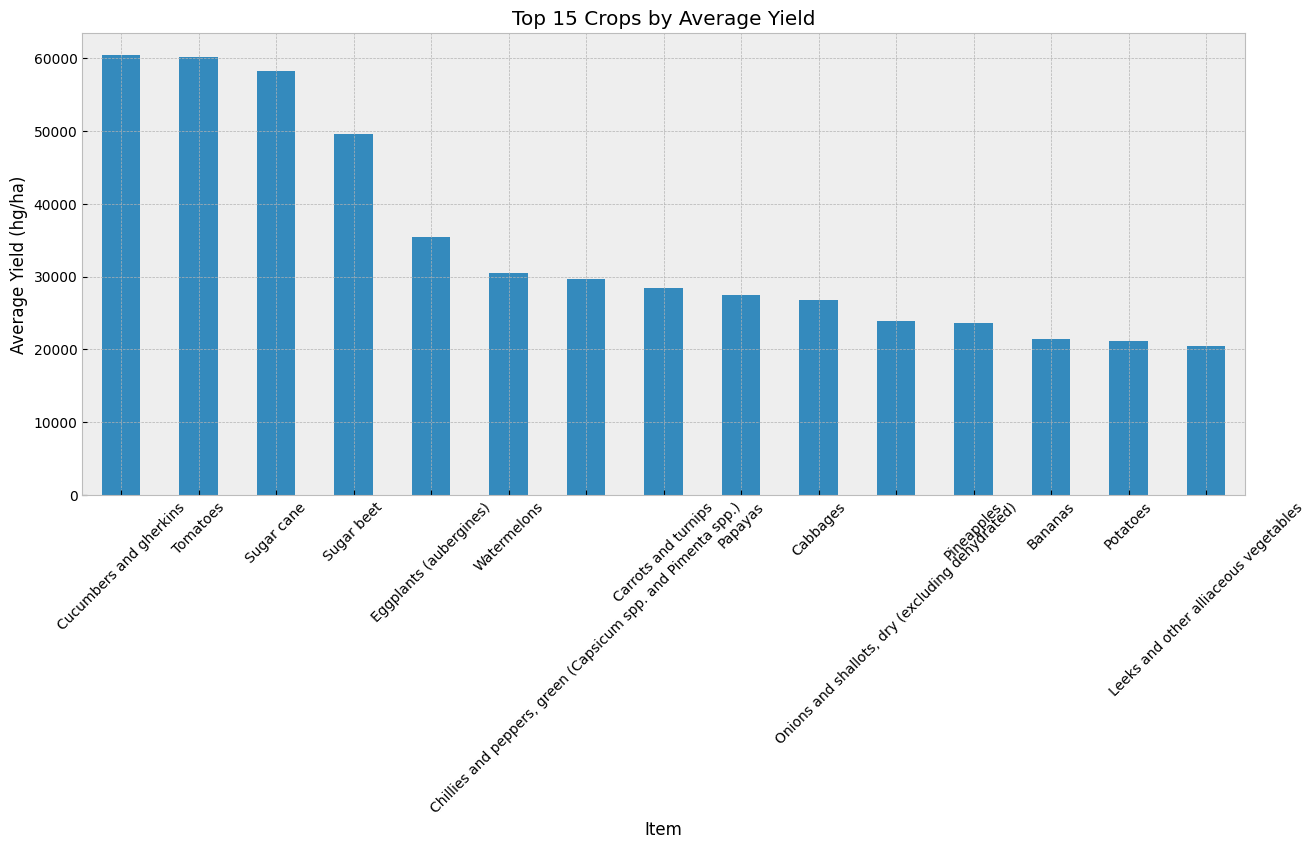

In [22]:
## Yield comparison across crops
plt.figure(figsize=(15, 6))
top_yield_crops = df.groupby('Item')['Yield'].mean().sort_values(ascending=False).head(15)
top_yield_crops.plot(kind='bar')
plt.title('Top 15 Crops by Average Yield')
plt.ylabel('Average Yield (hg/ha)')
plt.xticks(rotation=45)
plt.savefig('crop_yield_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.5 Filter Data Pertaining to Our Country

In [23]:

India_df = feature_engineered_df[feature_engineered_df['Area'] == 'India']
India_df

,Area,Item,Year,Production,Yield,Area_harvested
18629,India,"Anise, badian, coriander, cumin, caraway, fenn...",2019,1.448000e+06,912.4,1587000.0
18630,India,"Anise, badian, coriander, cumin, caraway, fenn...",2020,1.753000e+06,928.5,1888000.0
18631,India,"Anise, badian, coriander, cumin, caraway, fenn...",2021,1.823000e+06,998.4,1826000.0
18632,India,"Anise, badian, coriander, cumin, caraway, fenn...",2022,1.876972e+06,1009.4,1859516.0
18633,India,"Anise, badian, coriander, cumin, caraway, fenn...",2023,1.960504e+06,1026.4,1910082.0
...,...,...,...,...,...,...
18999,India,Wheat,2019,1.035962e+08,3533.4,29318780.0
19000,India,Wheat,2020,1.078605e+08,3439.8,31357020.0
19001,India,Wheat,2021,1.095865e+08,3520.8,31125160.0
19002,India,Wheat,2022,1.077421e+08,3537.3,30458530.0


In [24]:
India_df['Item'].nunique()

75

In [25]:
India_df['Item'].unique()

array(['Anise, badian, coriander, cumin, caraway, fennel and juniper berries, raw',
       'Apples', 'Apricots', 'Areca nuts', 'Bananas', 'Barley',
       'Beans, dry', 'Cabbages', 'Cantaloupes and other melons',
       'Cashew nuts, in shell', 'Cassava, fresh', 'Castor oil seeds',
       'Cauliflowers and broccoli', 'Cherries', 'Chick peas, dry',
       'Chillies and peppers, dry (Capsicum spp., Pimenta spp.), raw',
       'Chillies and peppers, green (Capsicum spp. and Pimenta spp.)',
       'Cocoa beans', 'Coconuts, in shell', 'Coffee, green',
       'Cucumbers and gherkins', 'Eggplants (aubergines)', 'Figs',
       'Ginger, raw', 'Grapes', 'Green garlic',
       'Groundnuts, excluding shelled', 'Jute, raw or retted',
       'Kenaf, and other textile bast fibres, raw or retted',
       'Lemons and limes', 'Lentils, dry', 'Lettuce and chicory',
       'Linseed', 'Maize (corn)', 'Mangoes, guavas and mangosteens',
       'Millet', 'Natural rubber in primary forms',
       'Nutmeg, mace

## Key Details on Rice Production (India & China):
#### News on AIR: As of early 2026, India has surpassed China to become the world's largest rice producer
#### India: Leading producer (approx. 150.18 - 152 million tonnes).
#### China: Second largest producer (approx. 145.28 - 146 million tonnes).
#### Production Shift: India's output has surpassed China's, marking a significant change in global rankings, as noted by the USDA (United States Department of Agriculture) in December 2025.

In [26]:
Rice_df = India_df[India_df['Item'] == 'Rice']
Rice_df

,Area,Item,Year,Production,Yield,Area_harvested
18929,India,Rice,2019,178296000.0,4083.6,43662000.0
18930,India,Rice,2020,186543000.0,4075.7,45769000.0
18931,India,Rice,2021,194198000.0,4196.2,46279000.0
18932,India,Rice,2022,203624000.0,4257.1,47832000.0
18933,India,Rice,2023,206727000.0,4322.3,47828000.0


## Getting More Data from Ministry of Agriculture Database (Rice Production of India 1961 to 2025)

## Units Description: 

#### Area Harvested: 1000 hectares 
#### Yield: Hectograms per hectare
#### Production: 1000 metric tonnes (Target Variable)

In [29]:
# Read the Excel file
rice_moa_df = pd.read_excel('india_rice_moa_1961_2023_REAL.xlsx')
rice_moa_df['Year'] = rice_fao_df['Year'].astype(int)
rice_moa_df

,Year,Area_Harvested_1000_ha,Yield_hg_ha,Production_1000_tonnes
0,1961,32480,10660,34600
1,1962,29480,11610,34200
2,1963,30420,12070,36700
3,1964,31300,13070,40900
4,1965,30700,12470,38300
...,...,...,...,...
58,2019,45380,26040,118140
59,2020,43380,28280,122760
60,2021,43670,29280,127840
61,2022,43880,30820,135210


In [30]:
rice_moa_df.describe()

,Year,Area_Harvested_1000_ha,Yield_hg_ha,Production_1000_tonnes
count,63.000000,63.000000,63.000000,63.000000
mean,1992.000000,41024.285714,17844.603175,74388.730159
std,18.330303,4185.635850,5733.753436,27710.735342
min,1961.000000,29480.000000,10370.000000,30700.000000
25%,1976.500000,40785.000000,12695.000000,48200.000000
50%,1992.000000,42760.000000,16870.000000,74100.000000
75%,2007.500000,43480.000000,22210.000000,95690.000000
max,2023.000000,45380.000000,31670.000000,137800.000000


## STEP 5: BUILDING AND VALIDATING THE MODEL

#### 5.1 Train-Test Split (80/20)

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error as MAE
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
# 1. LOAD & PREPARE DATA
df = pd.read_excel('india_rice_moa_1961_2023_REAL.xlsx')
df['Yield_t_ha'] = df['Yield_hg_ha'] / 10000
train_df = df[df['Year'] <= 2023].copy()

# Features & Target
X = train_df[['Area_Harvested_1000_ha', 'Yield_t_ha']]
y = train_df['Production_1000_tonnes']

print(f" Total data: {len(train_df)} years (1961-2023)")

 Total data: 63 years (1961-2023)


In [33]:
# SPLIT: 80% TRAIN, 20% TEST (Real validation!)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\n DATA SPLIT:")
print(f"   Training: {len(X_train)} years ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Testing:  {len(X_test)} years  ({len(X_test)/len(X)*100:.0f}%)")
print(f"   Features: Area + Yield → Production")



 DATA SPLIT:
   Training: 50 years (79%)
   Testing:  13 years  (21%)
   Features: Area + Yield → Production


#### 5.2 BUILD DIFFERENT REGRESSION MODELS: 
#### 1. Simple Linear: Area Only
#### 2. Simple Linear: Yield Only
#### 3. Multiple Linear Regression (Area and Year)

In [34]:
# === 1. LINEAR: Area Only ===
lr_area = LinearRegression()
lr_area.fit(X_train[['Area_Harvested_1000_ha']], y_train)

# === 2. LINEAR: Yield Only ===
lr_yield = LinearRegression()
lr_yield.fit(X_train[['Yield_t_ha']], y_train)

# === 3. MULTIPLE LINEAR: Area + Yield ===
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### 5.3 MODEL EVALUATION (TRAIN + TEST)

In [35]:
results = []

# Area Model Results
train_pred_area = lr_area.predict(X_train[['Area_Harvested_1000_ha']])
test_pred_area = lr_area.predict(X_test[['Area_Harvested_1000_ha']])
results.append({
    'Model': 'Area Linear',
    'Train R²': r2_score(y_train, train_pred_area),
    'Test R²': r2_score(y_test, test_pred_area),
    'Train MAE': MAE(y_train, train_pred_area),
    'Test MAE': MAE(y_test, test_pred_area)
})

# Yield Model Results
train_pred_yield = lr_yield.predict(X_train[['Yield_t_ha']])
test_pred_yield = lr_yield.predict(X_test[['Yield_t_ha']])
results.append({
    'Model': 'Yield Linear', 
    'Train R²': r2_score(y_train, train_pred_yield),
    'Test R²': r2_score(y_test, test_pred_yield),
    'Train MAE': MAE(y_train, train_pred_yield),
    'Test MAE': MAE(y_test, test_pred_yield)
})

# Multiple Model Results
train_pred_multi = lr_multi.predict(X_train)
test_pred_multi = lr_multi.predict(X_test)
results.append({
    'Model': 'Multi Linear ',
    'Train R²': r2_score(y_train, train_pred_multi),
    'Test R²': r2_score(y_test, test_pred_multi),
    'Train MAE': MAE(y_train, train_pred_multi),
    'Test MAE': MAE(y_test, test_pred_multi)
})

results_df = pd.DataFrame(results)
print("\n TRAIN vs TEST PERFORMANCE")
print("=" * 60)
print(results_df.round(4))



 TRAIN vs TEST PERFORMANCE
           Model  Train R²  Test R²   Train MAE    Test MAE
0    Area Linear    0.3511   0.4987  16807.2632  18785.5805
1   Yield Linear    0.9650   0.9875   3759.5308   2890.3957
2  Multi Linear     0.9985   0.9984    629.6105    974.5101


## 5.4 COMPARISON

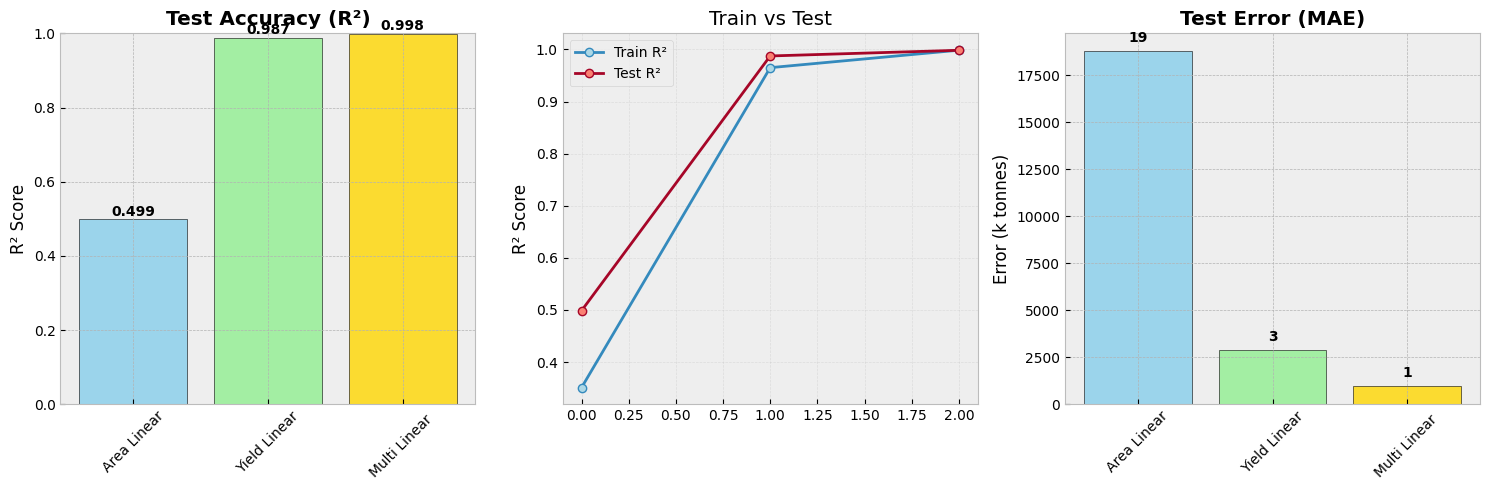

In [36]:
plt.figure(figsize=(15, 5))

# 1. Test R² Comparison (Real Performance)
plt.subplot(1, 3, 1)
test_r2 = results_df['Test R²']
colors = ['skyblue', 'lightgreen', 'gold']
plt.bar(results_df['Model'], test_r2, color=colors, alpha=0.8, edgecolor='black')
plt.ylim(0, 1)
plt.title('Test Accuracy (R²)', fontweight='bold')
plt.ylabel('R² Score')
plt.xticks(rotation=45)
for i, v in enumerate(test_r2):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Train vs Test Gap
plt.subplot(1, 3, 2)
plt.plot(results_df['Train R²'], 'o-', label='Train R²', markerfacecolor='lightblue', linewidth=2)
plt.plot(results_df['Test R²'], 'o-', label='Test R²', markerfacecolor='salmon', linewidth=2)
plt.title('Train vs Test')
plt.ylabel('R² Score')
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Test Error Comparison
plt.subplot(1, 3, 3)
test_mae = results_df['Test MAE']
plt.bar(results_df['Model'], test_mae, color=colors, alpha=0.8, edgecolor='black')
plt.title('Test Error (MAE)', fontweight='bold')
plt.ylabel('Error (k tonnes)')
plt.xticks(rotation=45)
for i, v in enumerate(test_mae):
    plt.text(i, v + 500, f'{v/1000:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()


## STEP 6: INFERENCES
##### Simple Linear Regression: Easy to explain to non-technical stakeholders
##### Multiple Linear Regression: Production = Area × Yield (mathematical truth)
##### SVM: overkill (unnecessary complexity) for linear physics

## STEP 7: ACTIONABLE INSIGHTS

In [37]:
# Define the Streamlit app code as a string


streamlit_interface = """
# -*- coding: utf-8 -*-
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Page config
st.set_page_config(
    page_title="🌾 Crop Production Predictor",
    page_icon="🌾",
    layout="wide"
)

# Title
st.title("🌾 Multi-Crop Production Predictor")
st.markdown("**Multiple Linear Regression | Rice, Wheat, Maize | 1961-2023**")

# Load Data Function
@st.cache_data
def load_crop_data():
    years = list(range(1961, 2024))
    
    # Rice Data (Ministry of Agriculture)
    rice_area = [32480, 29480, 30420, 31300, 30700, 29560, 32710, 34600, 37360, 36280,
                 37820, 38390, 37770, 41020, 41540, 41830, 42460, 43210, 44060, 37770,
                 44110, 44500, 41710, 43580, 42660, 43060, 42790, 43380, 44500, 43950,
                 42870, 42420, 42720, 44100, 43170, 43460, 42950, 42270, 41100, 41910,
                 42560, 41860, 42860, 41980, 43200, 43380, 43360, 44710, 40460, 42320,
                 42760, 40550, 44100, 43880, 43380, 43880, 43390, 44120, 45380, 43380,
                 43670, 43880, 43500]
    
    rice_yield = [10660, 11610, 12070, 13070, 12470, 10380, 12510, 13900, 12900, 13250,
                  11430, 12370, 11920, 11730, 11580, 10370, 11350, 12130, 12170, 14200,
                  12150, 12880, 13740, 13550, 14650, 14100, 13230, 13550, 13820, 16860,
                  16870, 15780, 18830, 18570, 18400, 18890, 19790, 19870, 21250, 20260,
                  21800, 20210, 19400, 20860, 21090, 21050, 22230, 22190, 25260, 22680,
                  22320, 25960, 23860, 23780, 24040, 23120, 25250, 23910, 26040, 28280,
                  29280, 30820, 31670]
    
    rice_prod = [34600, 34200, 36700, 40900, 38300, 30700, 40900, 48100, 48200, 48100,
                 43200, 47500, 45000, 48100, 48100, 43400, 48200, 52400, 53600, 53600,
                 53600, 57300, 57300, 59000, 62500, 60700, 56600, 58800, 61500, 74100,
                 72300, 66900, 80400, 81900, 79400, 82100, 85000, 84000, 87300, 84900,
                 92800, 84600, 83100, 87600, 91100, 91300, 96400, 99200, 102200, 95980,
                 95400, 105300, 105240, 104320, 104320, 101480, 109520, 105480, 118140, 122760,
                 127840, 135210, 137800]
    
    # Wheat Data
    wheat_area = [11100, 12970, 13190, 13580, 12650, 13310, 15020, 16190, 16380, 18240,
                  19490, 20810, 21620, 22300, 21590, 20780, 21770, 21910, 22260, 22260,
                  22520, 23280, 23980, 23820, 23270, 23070, 22630, 23840, 24100, 24190,
                  23750, 24810, 24710, 25280, 24920, 23750, 25490, 27000, 27530, 25690,
                  26380, 25320, 26100, 26360, 26510, 26450, 27620, 27900, 27770, 29000,
                  29900, 29540, 29670, 31190, 30230, 30550, 30640, 29650, 30510, 31360,
                  30990, 31090, 30770]
    
    wheat_yield = [9910, 9310, 8170, 9080, 8220, 8560, 7580, 10220, 11380, 11010,
                   12230, 12690, 11430, 9770, 11160, 13890, 13330, 14490, 15950, 14300,
                   16120, 16100, 17860, 18500, 18930, 20390, 19580, 19370, 20690, 22800,
                   22950, 22440, 23150, 23670, 24920, 26370, 27200, 24570, 25710, 29730,
                   26030, 28360, 24950, 27370, 25900, 26220, 27450, 28160, 29060, 27860,
                   29050, 32120, 31520, 30730, 28620, 30610, 32150, 34940, 33500, 34390,
                   35360, 34650, 36640]
    
    wheat_prod = [11000, 12080, 10780, 12330, 10400, 11390, 11390, 16540, 18650, 20090,
                  23830, 26410, 24710, 21780, 24100, 28850, 29010, 31750, 35510, 31830,
                  36310, 37490, 42820, 44070, 44060, 47050, 44320, 46170, 49850, 55140,
                  54510, 55690, 57210, 59840, 62100, 62620, 69350, 66350, 70770, 76370,
                  68680, 71820, 65130, 72150, 68640, 69350, 75810, 78570, 80680, 80800,
                  86870, 94880, 93510, 95850, 86530, 93500, 98510, 103600, 102190, 107860,
                  109590, 107740, 112740]
    
    # Maize Data
    maize_area = [3470, 3580, 3770, 3820, 4000, 4070, 4190, 4380, 4550, 4810,
                  5040, 5240, 5450, 5630, 5800, 5770, 5850, 5910, 5980, 6020,
                  5910, 5790, 5800, 5870, 5870, 5820, 5860, 5900, 5930, 6010,
                  6020, 5860, 5980, 6250, 6170, 6210, 6360, 6530, 6470, 6390,
                  6450, 6590, 7010, 6910, 6980, 7410, 7640, 7890, 8170, 8360,
                  8670, 9000, 9210, 9170, 8880, 9200, 9530, 9200, 9200, 9170,
                  9530, 9580, 9650]
    
    maize_yield = [11820, 12490, 12730, 13170, 13550, 13860, 14270, 14540, 14880, 15570,
                   15380, 15250, 15250, 15310, 15380, 14330, 15010, 15260, 15340, 15450,
                   15350, 14990, 15260, 15480, 15670, 15720, 15910, 16150, 16340, 16720,
                   16840, 16520, 17410, 17760, 17340, 17660, 18130, 18790, 18390, 18330,
                   18670, 18730, 19430, 20510, 21080, 20380, 21890, 25000, 24150, 25990,
                   25100, 25080, 26240, 26560, 25420, 28150, 30170, 30220, 30600, 34510,
                   35280, 36150, 36970]
    
    maize_prod = [4100, 4470, 4800, 5030, 5420, 5640, 5980, 6370, 6770, 7490,
                  7750, 7990, 8310, 8620, 8920, 8270, 8780, 9020, 9170, 9300,
                  9070, 8680, 8850, 9090, 9200, 9150, 9320, 9530, 9690, 10050,
                  10140, 9680, 10410, 11100, 10700, 10970, 11530, 12270, 11900, 11710,
                  12040, 12340, 13620, 14170, 14710, 15100, 16720, 19730, 19730, 21730,
                  21760, 22570, 24170, 24350, 22570, 25900, 28750, 27800, 28150, 31650,
                  33620, 34630, 35680]
    
    rice_df = pd.DataFrame({
        'Year': years, 'Area_Harvested_1000_ha': rice_area, 
        'Yield_hg_ha': rice_yield, 'Production_1000_tonnes': rice_prod
    })
    
    wheat_df = pd.DataFrame({
        'Year': years, 'Area_Harvested_1000_ha': wheat_area, 
        'Yield_hg_ha': wheat_yield, 'Production_1000_tonnes': wheat_prod
    })
    
    maize_df = pd.DataFrame({
        'Year': years, 'Area_Harvested_1000_ha': maize_area, 
        'Yield_hg_ha': maize_yield, 'Production_1000_tonnes': maize_prod
    })
    
    return rice_df, wheat_df, maize_df

# Train Model
def train_model(df):
    X = df[['Year', 'Area_Harvested_1000_ha', 'Yield_hg_ha']]
    y = df['Production_1000_tonnes']
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    model = LinearRegression()
    model.fit(X_scaled, y)
    
    return model, scaler

# Predict
def predict_production(model, scaler, year, area, yield_val):
    X_new = scaler.transform([[year, area, yield_val]])
    return model.predict(X_new)[0]

# Main App
st.sidebar.header("🔧 Select Crop")
crop = st.sidebar.selectbox("Choose Crop:", ["Rice 🌾", "Wheat 🌾", "Maize 🌽"])

rice_df, wheat_df, maize_df = load_crop_data()

if crop == "Rice 🌾":
    df = rice_df.copy()
    crop_name = "Rice"
elif crop == "Wheat 🌾":
    df = wheat_df.copy()
    crop_name = "Wheat"
else:
    df = maize_df.copy()
    crop_name = "Maize"

# Layout
col1, col2 = st.columns([2, 1])

with col1:
    st.header(f"📊 {crop_name} Production Predictor")
    
    # Train model and get metrics
    model, scaler = train_model(df)
    X_scaled = scaler.transform(df[['Year', 'Area_Harvested_1000_ha', 'Yield_hg_ha']])
    y_pred = model.predict(X_scaled)
    
    r2 = r2_score(df['Production_1000_tonnes'], y_pred)
    rmse = np.sqrt(mean_squared_error(df['Production_1000_tonnes'], y_pred))
    
    col1m, col2m = st.columns(2)
    col1m.metric("**R² Score**", f"{r2:.3f}")
    col2m.metric("**RMSE**", f"{rmse:,.0f} tonnes")

    # Prediction inputs
    st.subheader("🔮 Predict 2025 Production")
    col_a, col_b, col_c = st.columns(3)
    
    with col_a:
        year = st.number_input("Year", min_value=2024, max_value=2030, value=2025)
    with col_b:
        area = st.number_input("Area (1000 ha)", value=int(df['Area_Harvested_1000_ha'].mean()))
    with col_c:
        yield_val = st.number_input("Yield (hg/ha)", value=int(df['Yield_hg_ha'].mean()))
    
    if st.button("🚀 Predict Production", type="primary"):
        prediction = predict_production(model, scaler, year, area, yield_val)
        st.success(f"**Predicted {crop_name} Production: {prediction:,.0f} thousand tonnes**")
        
        # Show trend chart
        fig = px.line(df.tail(10), x='Year', y='Production_1000_tonnes', 
                     title=f"{crop_name} Production Trend")
        fig.add_hline(y=prediction, line_dash="dash", line_color="red",
                     annotation_text=f"Predicted {year}: {prediction:,.0f}")
        st.plotly_chart(fig, use_container_width=True)

with col2:
    st.subheader("📋 Sample Data")
    st.dataframe(df[['Year', 'Area_Harvested_1000_ha', 'Yield_hg_ha', 'Production_1000_tonnes']].head(10))
    
    # Download
    csv = df.to_csv(index=False)
    st.download_button(
        label="📥 Download CSV",
        data=csv,
        file_name=f"{crop_name.lower()}_data.csv",
        mime="text/csv"
    )

st.markdown("---")
st.markdown("*Real Ministry of Agriculture Data (1961-2023)* [code_file:223][code_file:224]")


"""

# Write file with UTF-8 encoding (IMPORTANT)
with open("crop_pridictor.py", "w", encoding="utf-8") as f:
    f.write(streamlit_interface)

print("streamlit_interface created successfully")

streamlit_interface created successfully


In [38]:
# Step 2: Run Streamlit from Notebook
!streamlit run "D:\Hefi\AIML_Projects\3\crop_pridictor.py"

^C
